# 03 · Wet-antenna tails: the non-rain term with memory

**What this notebook covers.** With the rain along the path known, the non-rain term is
what the path law leaves over,

$$\hat\delta(t) = A_{obs}(t) - a\,R(t)^{b} L .$$

A wet antenna is a water film: it builds up while it rains and dries afterwards, so
$\hat\delta$ has *memory* - a tail after every event that no rain-rate model can
produce. The proposal learns $\dot\delta = F(\delta, R)$ per link with weak-form SINDy.
This notebook prepares that problem twice: first in simulation, with the dynamic
wet-antenna model of `core.simulation.wet_antenna` as known truth, then on OpenMRG with
the radar along the path as $R$. Both parts extract the post-event drying tails, fit
their drying time, and fit the literature models (constant, Schleiss 2013, Pastorek
2021) per link: the baseline a learned model must beat.

**Prerequisites.** Notebook 02 (the data, the chain, the event split). Runs in about
three minutes.

**Contents**
1. A wet antenna with memory
2. A simulated network
3. Drying tails in simulation
4. Literature models in simulation
5. OpenMRG: isolating the non-rain term
6. OpenMRG: drying tails
7. OpenMRG: literature models per link
8. Your method goes here

In [1]:
import contextlib
import io
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("projects/physics_ml/path_law_1d")
sys.path.insert(0, str(ROOT / "src"))

from core.cml.baseline import median_dry_baseline
from core.cml.power_law import attenuation_from_rain
from core.opensense import evaluation as ev
from core.opensense import example_data, retrieval
from core.simulation import cml_network as cn
from core.simulation import fields_1d as f1
from core.simulation import generators as gen
from core.simulation import spacetime as st
from core.simulation import wet_antenna as wa
from core.simulation.rain_fields import Grid
from path_law_1d import events as pe
from path_law_1d import simulate as sm
from path_law_1d import tails as tl

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)

## 1. A wet antenna with memory

`wa.DynamicWetAntenna` relaxes towards the rain-dependent equilibrium of Pastorek et al.
(2021), $\delta_{eq}(R) = \delta_{max}(1 - e^{-\gamma R})$, with one time constant while
it wets and another while it dries:

$$\frac{d\delta}{dt} = \frac{\delta_{eq}(R) - \delta}{\tau}, \qquad
\tau = \begin{cases}\tau_{wet} & \delta < \delta_{eq}(R)\\ \tau_{dry} & \text{otherwise.}\end{cases}$$

Driven by one day of Neyman-Scott rain (`core.simulation.fields_1d`), next to the three
literature models driven by the same rain. All three drop to zero when the rain stops.

DynamicWetAntenna(a_max_db=2.0, gamma_per_mm_h=0.3, zeta=1.0, tau_wet_min=5.0, tau_dry_min=30.0)


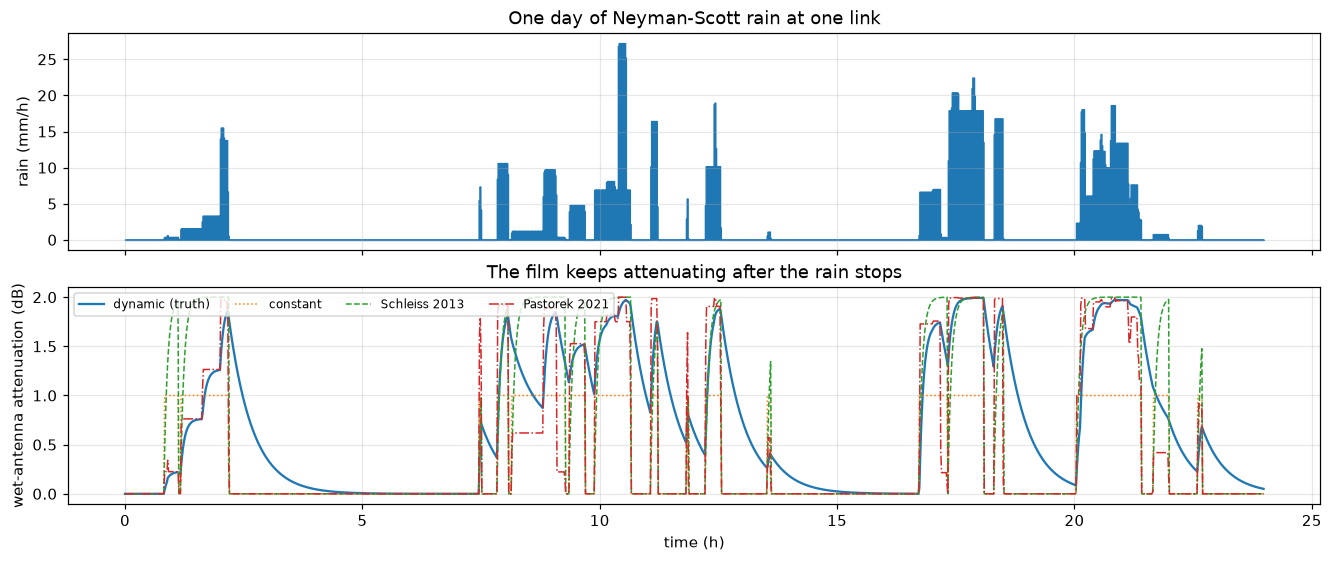

In [2]:
WA = wa.DynamicWetAntenna()                   # the simulator's truth
print(WA)
DT = 1.0
rain_1d = f1.neyman_scott(24, DT, np.random.default_rng(3), storm_rate_per_h=0.15,
                          mean_cells=6, cell_intensity_mm_h=6)
t_h = np.arange(rain_1d.size) * DT / 60
models = {
    "dynamic (truth)": WA.simulate(rain_1d, DT),
    "constant": wa.waa_constant(rain_1d >= 0.1, 1.0),
    "Schleiss 2013": wa.waa_schleiss_2013(rain_1d >= 0.1, WA.a_max_db, 15.0, DT),
    "Pastorek 2021": wa.waa_pastorek_2021(rain_1d, WA.a_max_db, WA.gamma_per_mm_h, WA.zeta),
}
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, constrained_layout=True)
axes[0].fill_between(t_h, rain_1d, color="C0", step="pre")
axes[0].set(ylabel="rain (mm/h)", title="One day of Neyman-Scott rain at one link")
for (name, d), ls in zip(models.items(), ("-", ":", "--", "-.")):
    axes[1].plot(t_h, d, ls, lw=1.5 if name.startswith("dyn") else 1, label=name)
axes[1].set(xlabel="time (h)", ylabel="wet-antenna attenuation (dB)",
            title="The film keeps attenuating after the rain stops")
axes[1].legend(fontsize=8, ncol=4)
plt.show()

## 2. A simulated network

Convective cells that are born, grow and decay while they move
(`core.simulation.spacetime`, `lifecycle`), 12 hours at 2-minute steps, over 150 links
of 0.3-12 km. `cml_network.forward_series` runs the sensor chain with the dynamic wet
antenna, a per-link baseline offset, receiver noise and 0.1 dB quantization. The baseline
is then estimated as in practice, from samples long after any rain
(`core.cml.baseline.median_dry_baseline`), and $\hat\delta$ is formed twice: with the
exact path integral, and with the linear law, as on real data, where the exact integral
is unknown.

In [3]:
GRID = Grid(n=128, dx_km=0.5)
DT_SIM = 2.0
seq = st.simulate(gen.make("convective_cells", n_cells=10), GRID, n_steps=360, dt_min=DT_SIM,
                  evolution="lifecycle", lifetime_min=60, seed=1)
net = sm.random_links(GRID, 150, length_km=(0.3, 12.0), seed=2)
cfg = cn.SensorConfig(baseline_sigma_db=0.5, noise_sigma_db=0.1, quantization_db=0.1)
sim = cn.forward_series(seq.frames, GRID, net, DT_SIM, cfg, wet_antenna=WA)
R_sim = sim["R_path_true"]

since = tl.minutes_since_rain(R_sim, DT_SIM)
base = median_dry_baseline(sim["A_observed"], since > 240)
base = np.where(np.isfinite(base), base, np.nanmedian(sim["A_observed"], axis=1))
dhat_exact = sim["A_observed"] - base[:, None] - sim["A_rain"]
dhat_sim = sim["A_observed"] - base[:, None] - sim["A_uniform"]       # with the linear law
print(f"{net.n_links} links, {R_sim.shape[1]} steps; wet {np.mean(R_sim >= 0.1):.0%} of link-steps; "
      f"baseline error median {np.median(np.abs(base - sim['baseline'])):.3f} dB")

wet = R_sim >= 0.1
lbin = sm.length_bin(net.length_km, (0, 2, 4, 8, 12))
rows = {}
for b in lbin.categories:
    sel = np.asarray(lbin == b)[:, None] & wet
    rows[b] = {"wet samples": int(sel.sum()),
               "rms(delta_hat - truth), exact law (dB)": np.sqrt(np.mean((dhat_exact - sim["A_waa"])[sel] ** 2)),
               "rms(delta_hat - truth), linear law (dB)": np.sqrt(np.mean((dhat_sim - sim["A_waa"])[sel] ** 2))}
pd.DataFrame(rows).T.astype({"wet samples": int}).rename_axis("link length")

150 links, 360 steps; wet 22% of link-steps; baseline error median 0.146 dB


,wet samples,"rms(delta_hat - truth), exact law (dB)","rms(delta_hat - truth), linear law (dB)"
link length,,,
0-2 km,5386,0.382,0.384
2-4 km,2523,0.310,0.338
4-8 km,1972,0.296,0.994
8-12 km,1760,0.407,1.331


During rain, $\hat\delta$ formed with the linear law carries the path-law error as well,
and more of it on long links: the two problems of the proposal are entangled in the
same residual. After the rain there is no path term, and the tail is the film alone.

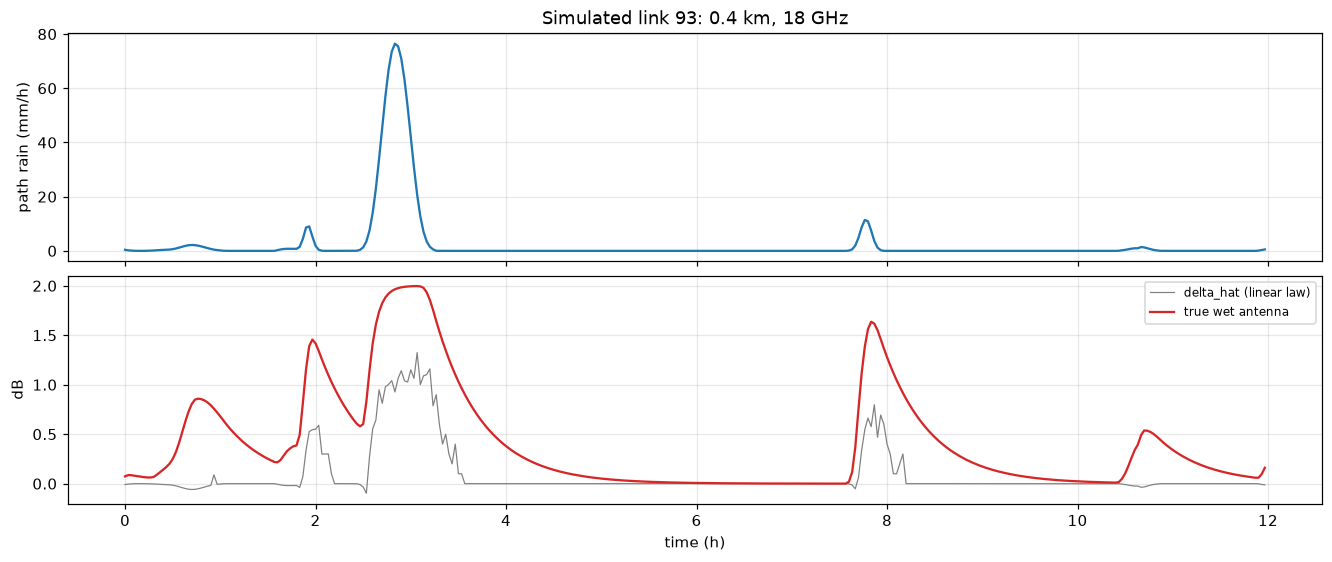

In [4]:
j = int(np.argmax(np.where(net.length_km < 2, (wet.sum(1) > 20) * sim["A_waa"].max(1), 0)))
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, constrained_layout=True)
th = np.arange(R_sim.shape[1]) * DT_SIM / 60
axes[0].plot(th, R_sim[j], color="C0")
axes[0].set(ylabel="path rain (mm/h)", title=f"Simulated link {j}: {net.length_km[j]:.1f} km, "
            f"{net.freq_ghz[j]:.0f} GHz")
axes[1].plot(th, dhat_sim[j], color="0.5", lw=0.8, label="delta_hat (linear law)")
axes[1].plot(th, sim["A_waa"][j], color="C3", label="true wet antenna")
axes[1].set(xlabel="time (h)", ylabel="dB")
axes[1].legend(fontsize=8)
plt.show()

## 3. Drying tails in simulation

`tl.tail_table` takes every dry spell that follows at least 10 minutes of rain, up to
3 hours or the next rain, and fits $\hat\delta = A e^{-t/\tau} + c$. Tails that start
above 0.5 dB carry a measurable film; their drying time should come back as the
simulator's $\tau_{dry}$.

580 tails, 267 start above 0.5 dB; their median drying time 28.2 min (truth 30 min), IQR 22.6-33.4 min


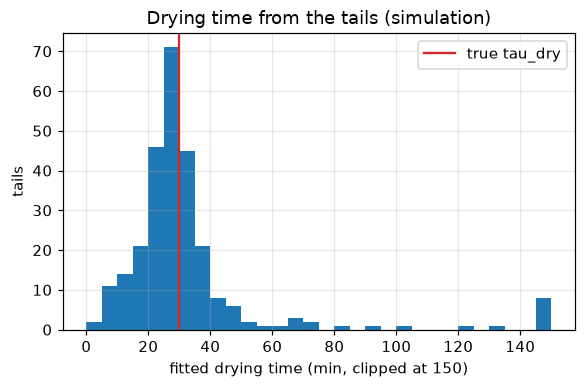

In [5]:
tails_sim = tl.tail_table(dhat_sim, R_sim, DT_SIM)
clear_sim = tails_sim[(tails_sim.delta0_db > 0.5) & (tails_sim.rmse_db < 0.5)]
print(f"{len(tails_sim)} tails, {len(clear_sim)} start above 0.5 dB; their median drying time "
      f"{clear_sim.tau_min.median():.1f} min (truth {WA.tau_dry_min:.0f} min), "
      f"IQR {clear_sim.tau_min.quantile(0.25):.1f}-{clear_sim.tau_min.quantile(0.75):.1f} min")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(clear_sim.tau_min.clip(upper=150), bins=np.arange(0, 155, 5), color="C0")
ax.axvline(WA.tau_dry_min, color="C3", label="true tau_dry")
ax.set(xlabel="fitted drying time (min, clipped at 150)", ylabel="tails",
       title="Drying time from the tails (simulation)")
ax.legend()
plt.show()

## 4. Literature models in simulation

`tl.fit_literature` fits the three static models per link by least squares on the first
six hours and `tl.waa_scores` scores them on the last six, in three regimes: during
rain, in the tail (up to 3 hours after rain) and long after rain. "none" predicts zero;
"dynamic (truth)" is the simulator's own film: its error is what noise, quantization,
baseline error and, in rain, the path-law error leave.

In [6]:
half = np.arange(R_sim.shape[1]) < R_sim.shape[1] // 2
params_sim, preds_sim = tl.fit_literature(dhat_sim, R_sim, DT_SIM, fit_mask=half)
preds_sim["dynamic (truth)"] = sim["A_waa"]
preds_sim["none"] = np.zeros_like(dhat_sim)
tl.waa_scores(dhat_sim, preds_sim, R_sim, DT_SIM, eval_mask=~half)

,rmse_rain_db,rmse_tail_db,rmse_dry_db,n_rain,n_tail,n_dry
model,,,,,,
constant,0.683,0.251,0.089,4718,19066,3216
schleiss,0.632,0.251,0.089,4718,19066,3216
pastorek,0.565,0.249,0.102,4718,19066,3216
dynamic (truth),0.597,0.180,0.090,4718,19066,3216
none,0.764,0.251,0.089,4718,19066,3216


In the tail the constant and Schleiss models score exactly as "none", and Pastorek
differs only through drizzle below the 0.1 mm/h wet threshold: none of them has memory.
The gap between them and the truth in the tail is what a learned $F(\delta, R)$ can
close. In rain, the fitted static models can even beat the truth, because they also
absorb part of the path-law error.

## 5. OpenMRG: isolating the non-rain term

The same eight days and links as notebook 02. Two choices differ from its chain, both
so that the tail survives into $\hat\delta$:

* the **baseline** comes from samples the radar calls dry *and* that are more than
  6 hours after radar rain (passed to `retrieval.retrieve_dataset` as the wet mask), so
  the level from before each event is held through its tail. With the rolling-std mask,
  or a shorter hold, the slow end of a tail enters the baseline and is subtracted away;
* **no wet-antenna correction**, so $A_{obs}$ keeps the film.

$R$ is the radar along the path, held over its 5-minute step; the linear law uses each
sublink's own ITU-R coefficients (`core.cml.power_law.attenuation_from_rain`), and the
two sublinks' $\hat\delta$ are averaged.

In [7]:
with contextlib.redirect_stdout(io.StringIO()):
    data = example_data.load("openmrg", "8d")
cml_10s, radar = data["cml"], data["radar"]
cml = cml_10s[["tsl", "rsl"]].resample(time="1min").mean()
cml = cml.assign_coords({c: cml_10s[c] for c in cml_10s.coords if "time" not in cml_10s[c].dims})
LABEL = example_data.DATASETS["openmrg"].accumulation_label
times = cml.time.values

radar_path = ev.radar_along_links(radar.R, cml)
R_real = radar_path.reindex(time=times, method="ffill").transpose("cml_id", "time").values
since_real = tl.minutes_since_rain(R_real, 1.0)
HOLD_MIN = 360                                   # baseline held this long after radar rain
wet_mask = xr.DataArray(since_real.T <= HOLD_MIN, dims=("time", "cml_id"),
                        coords={"time": times, "cml_id": cml.cml_id.values})
chain = retrieval.retrieve_dataset(cml, retrieval.RetrievalConfig.for_interval(60, waa_model="none"),
                                   wet=wet_mask)
A_obs = chain.A_obs.transpose("cml_id", "sublink_id", "time").values
L = cml.length_km.values
f_ghz = cml.frequency_ghz.transpose("cml_id", "sublink_id").values
pol = cml.polarization.transpose("cml_id", "sublink_id").values
A_lin = attenuation_from_rain(R_real[:, None, :], L[:, None, None], f_ghz[:, :, None], pol[:, :, None])
dhat_real = np.nanmean(A_obs - A_lin, axis=1)                         # (links, time)
events = pe.split_events(pe.radar_events(radar.R, cml, label=LABEL))
train = pe.event_mask(times, events, "train")
test = pe.event_mask(times, events, "test")
print(f"delta_hat: {dhat_real.shape[0]} links x {dhat_real.shape[1]} minutes; "
      f"{(events.split == 'train').sum()} train and {(events.split == 'test').sum()} test events")

delta_hat: 364 links x 11520 minutes; 4 train and 3 test events


One short link through the storm of 25 July (a test event): the observed excess, the
linear law driven by the radar, and what is left.

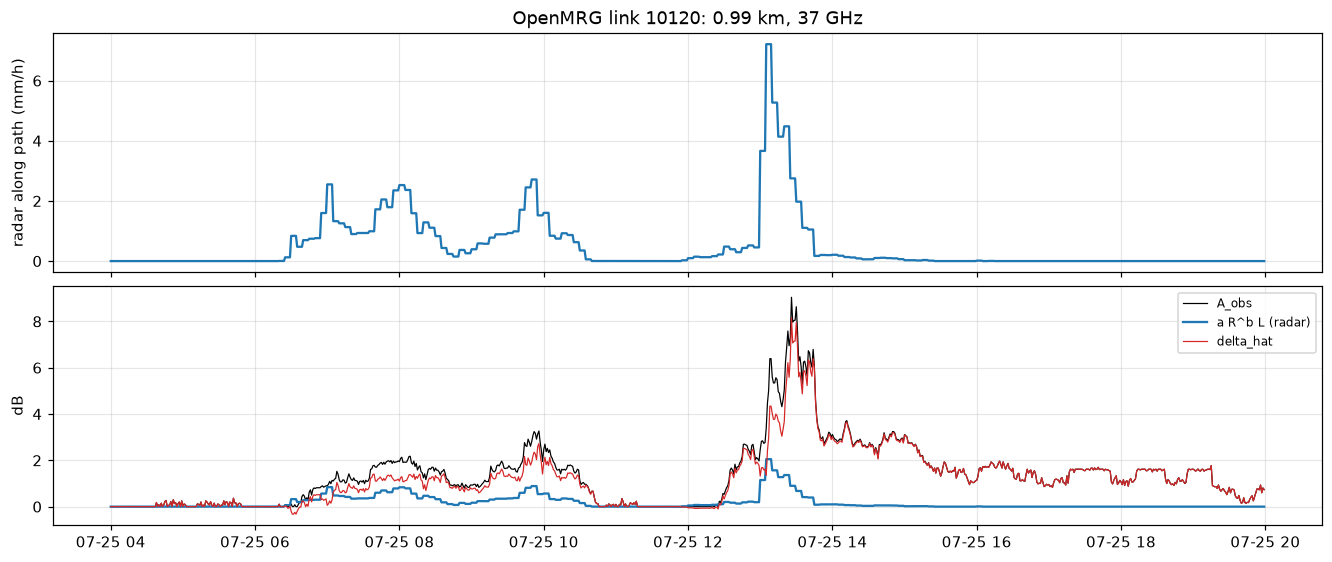

In [8]:
tails_real = tl.tail_table(dhat_real, R_real, 1.0, link_ids=cml.cml_id.values, times=times)
tails_real["L_km"] = pd.Series(L, index=cml.cml_id.values).reindex(tails_real.link).values
clear = tails_real[(tails_real.delta0_db > 0.5) & (tails_real.rmse_db < 0.5)]
short = clear[clear.L_km < 1.5].link.value_counts()
LINK = int(short.index[0])
k = int(np.flatnonzero(cml.cml_id.values == LINK)[0])
win = (times >= np.datetime64("2015-07-25T04:00")) & (times < np.datetime64("2015-07-25T20:00"))
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, constrained_layout=True)
axes[0].plot(times[win], R_real[k, win], color="C0")
axes[0].set(ylabel="radar along path (mm/h)",
            title=f"OpenMRG link {LINK}: {L[k]:.2f} km, {f_ghz[k, 0]:.0f} GHz")
axes[1].plot(times[win], np.nanmean(A_obs[k], axis=0)[win], color="k", lw=0.8, label="A_obs")
axes[1].plot(times[win], np.nanmean(A_lin[k], axis=0)[win], color="C0", label="a R^b L (radar)")
axes[1].plot(times[win], dhat_real[k, win], color="C3", lw=0.8, label="delta_hat")
axes[1].set(ylabel="dB")
axes[1].legend(fontsize=8)
plt.show()

## 6. OpenMRG: drying tails

The same tail extraction and fit as in simulation, on every link. Tails starting above
0.5 dB with a fit residual below 0.5 dB are kept. Their drying times are what the
drying time of a learned model should be checked against; which links have a wet
antenna at all is a question for the project.

In [9]:
print(f"{len(tails_real)} tails on {tails_real.link.nunique()} links; {len(clear)} start above 0.5 dB "
      f"on {clear.link.nunique()} links")
by_len = clear.groupby(pd.cut(clear.L_km, [0, 1, 2, 4, 8, 20]), observed=True).agg(
    tails=("tau_min", "size"), links=("link", "nunique"), median_delta0_db=("delta0_db", "median"),
    median_tau_min=("tau_min", "median"), tau_p25=("tau_min", lambda x: x.quantile(0.25)),
    tau_p75=("tau_min", lambda x: x.quantile(0.75)))
by_len.index.name = "link length (km)"
by_len

6335 tails on 354 links; 3116 start above 0.5 dB on 354 links


,tails,links,median_delta0_db,median_tau_min,tau_p25,tau_p75
link length (km),,,,,,
"(0, 1]",559,64,1.089,8.909,4.784,21.849
"(1, 2]",797,94,1.075,9.371,4.619,27.950
"(2, 4]",1020,118,1.075,8.515,3.998,27.095
"(4, 8]",607,65,1.111,8.913,4.279,33.684
"(8, 20]",133,13,1.171,10.878,5.426,47.286


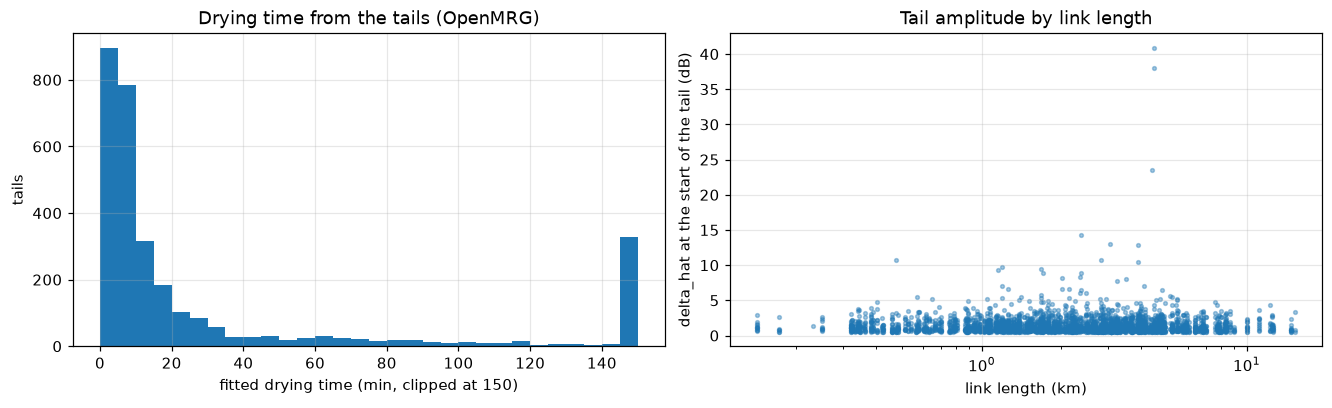

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True)
axes[0].hist(clear.tau_min.clip(upper=150), bins=np.arange(0, 155, 5), color="C0")
axes[0].set(xlabel="fitted drying time (min, clipped at 150)", ylabel="tails",
            title="Drying time from the tails (OpenMRG)")
axes[1].scatter(clear.L_km, clear.delta0_db, s=6, alpha=0.4)
axes[1].set(xscale="log", xlabel="link length (km)", ylabel="delta_hat at the start of the tail (dB)",
            title="Tail amplitude by link length")
plt.show()

## 7. OpenMRG: literature models per link

Fitted per link on the training events, scored on the test events, pooled over links.

In [11]:
params_real, preds_real = tl.fit_literature(dhat_real, R_real, 1.0, fit_mask=train)
preds_real["none"] = np.zeros_like(dhat_real)
print("median fitted parameters over links:")
print(params_real.median().round(3).to_string())
literature = tl.waa_scores(dhat_real, preds_real, R_real, 1.0, eval_mask=test)
literature

median fitted parameters over links:
constant_db             1.088
schleiss_waa_max_db     1.488
schleiss_tau_min       30.000
pastorek_a_max_db       2.548
pastorek_d              0.800
pastorek_zeta           0.300


,rmse_rain_db,rmse_tail_db,rmse_dry_db,n_rain,n_tail,n_dry
model,,,,,,
constant,1.964,1.062,0.353,310840,299890,173035
schleiss,2.027,1.062,0.353,310840,299890,173035
pastorek,2.098,1.011,0.371,310840,299890,173035
none,2.036,1.062,0.353,310840,299890,173035


## 8. Your method goes here

Learn $\dot\delta = F(\delta, R)$ per link from `dhat_real` and `R_real` on the training
events (weak-form SINDy: `pysindy` with a weak library and $R$ as a control input; see
`projects/physics_ml/discovery/notebooks/01_sindy_basics.ipynb`), integrate it over the
test events, and score it with `tl.waa_scores` next to the literature models. Check it
first on `dhat_sim` / `R_sim`, where the answer is `WA`; then compare its drying time
with the tails of section 6.

In [12]:
# ---- your method goes here ------------------------------------------------------
# model = ...fit on dhat_real[:, train], R_real[:, train]...
# delta_method = ...integrate the model over every time step, per link...
delta_method = preds_real["schleiss"]           # placeholder: the Schleiss fit
tl.waa_scores(dhat_real, {"your method": delta_method, **preds_real}, R_real, 1.0, eval_mask=test)

,rmse_rain_db,rmse_tail_db,rmse_dry_db,n_rain,n_tail,n_dry
model,,,,,,
your method,2.027,1.062,0.353,310840,299890,173035
constant,1.964,1.062,0.353,310840,299890,173035
schleiss,2.027,1.062,0.353,310840,299890,173035
pastorek,2.098,1.011,0.371,310840,299890,173035
none,2.036,1.062,0.353,310840,299890,173035


## References

* Pastorek, J., Fencl, M., Rieckermann, J., and Bares, V. (2021). Precipitation estimates
  from commercial microwave links: Practical approaches to wet-antenna correction.
  *IEEE Trans. Geosci. Remote Sens.*, 60, 1-9.
  [doi:10.1109/TGRS.2021.3110004](https://doi.org/10.1109/TGRS.2021.3110004)
* Schleiss, M., Rieckermann, J., and Berne, A. (2013). Quantification and modeling of
  wet-antenna attenuation for commercial microwave links. *IEEE Geosci. Remote Sens.
  Lett.*, 10(5), 1195-1199. [doi:10.1109/LGRS.2012.2236074](https://doi.org/10.1109/LGRS.2012.2236074)
* Messenger, D. A., and Bortz, D. M. (2021). Weak SINDy: Galerkin-based data-driven model
  selection. *Multiscale Model. Simul.*, 19(3), 1474-1497.
* Cowpertwait, P. S. P. (1991). Further developments of the Neyman-Scott clustered point
  process for modeling rainfall. *Water Resour. Res.*, 27(7), 1431-1438.